In [19]:
# 필요하면 한 번만 실행
!pip install numpy pandas scipy matplotlib statsmodels openpyxl

# 기본 설정

In [20]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

DATA_FILE = "your_data.csv"      # 예: arrivals.csv, replications.csv
COLUMN = 'interarrival'                    # 예: "interarrival"; None이면 첫 numeric column 사용
OUTDIR = "analysis_results"
CONFIDENCE = 0.95

os.makedirs(OUTDIR, exist_ok=True)

# 데이터 불러오기

In [21]:
ext = os.path.splitext(DATA_FILE)[1].lower()

if ext in [".xlsx", ".xls"]:
    df = pd.read_excel(DATA_FILE)
else:
    df = pd.read_csv(DATA_FILE)

display(df.head())
display(df.dtypes)

if COLUMN is None:
    COLUMN = df.select_dtypes(include=[np.number]).columns[0]

x = df[COLUMN].dropna().astype(float).to_numpy()
x = x[np.isfinite(x)]

print("Selected column:", COLUMN)
print("n =", len(x))

,observation,interarrival,service_time,demand
0,1,1.8908,1.0311,2
1,2,1.0430,3.3760,2
2,3,6.3433,4.2272,5
3,4,0.0224,6.4708,4
4,5,1.3736,1.0423,4


observation       int64
interarrival    float64
service_time    float64
demand            int64
dtype: object

Selected column: interarrival
n = 120


# 기초 통계량

In [22]:
summary = pd.Series({
    "n": len(x),
    "mean": np.mean(x),
    "std": np.std(x, ddof=1),
    "variance": np.var(x, ddof=1),
    "min": np.min(x),
    "q05": np.quantile(x, 0.05),
    "q25": np.quantile(x, 0.25),
    "median": np.median(x),
    "q75": np.quantile(x, 0.75),
    "q95": np.quantile(x, 0.95),
    "max": np.max(x),
    "skewness": stats.skew(x, bias=False),
    "kurtosis_excess": stats.kurtosis(x, bias=False),
})

display(summary.to_frame("value"))
summary.to_csv(os.path.join(OUTDIR, "input_summary.csv"))

,value
n,120.000000
mean,3.382686
std,3.722614
variance,13.857852
min,0.000400
q05,0.157545
q25,0.967350
median,1.984300
q75,4.224825
q95,12.360315


# Histogram / Emperical CDF

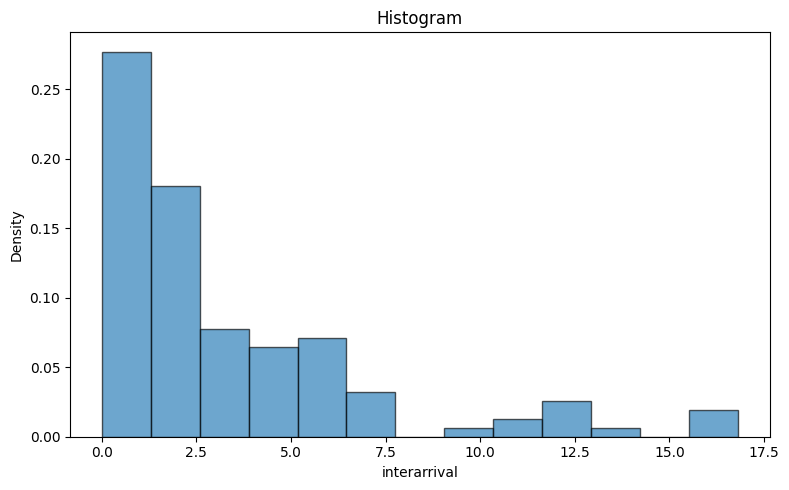

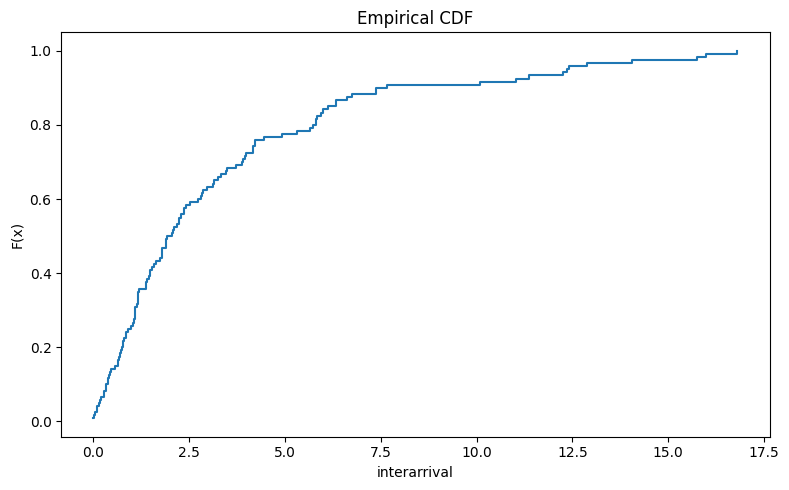

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(x, bins="auto", density=True, alpha=0.65, edgecolor="black")
plt.title("Histogram")
plt.xlabel(COLUMN)
plt.ylabel("Density")
plt.tight_layout()
plt.show()

xs = np.sort(x)
ps = np.arange(1, len(xs) + 1) / len(xs)

plt.figure(figsize=(8, 5))
plt.step(xs, ps, where="post")
plt.title("Empirical CDF")
plt.xlabel(COLUMN)
plt.ylabel("F(x)")
plt.tight_layout()
plt.show()

# 분포 적합

In [24]:
continuous_dists = {
    "normal": stats.norm,
    "exponential": stats.expon,
    "gamma": stats.gamma,
    "lognormal": stats.lognorm,
    "weibull": stats.weibull_min,
    "uniform": stats.uniform,
    "triangular": stats.triang,
    "beta": stats.beta,
}

fit_rows = []

for name, dist in continuous_dists.items():
    try:
        params = dist.fit(x)
        logpdf = dist.logpdf(x, *params)
        log_likelihood = np.sum(np.where(np.isfinite(logpdf), logpdf, -1e100))

        k = len(params)
        n = len(x)
        aic = 2 * k - 2 * log_likelihood
        bic = math.log(n) * k - 2 * log_likelihood

        ks_stat, ks_p = stats.kstest(x, lambda v: dist.cdf(v, *params))

        bins = max(5, int(round(math.sqrt(n))))
        probs = np.linspace(0, 1, bins + 1)
        edges = dist.ppf(probs, *params)
        edges[0], edges[-1] = -np.inf, np.inf
        edges = np.unique(edges)

        observed, _ = np.histogram(x, bins=edges)
        expected = n * np.diff(dist.cdf(edges, *params))
        mask = expected >= 5

        if np.sum(mask) >= 2:
            chi_stat = np.sum((observed[mask] - expected[mask])**2 / expected[mask])
            df_chi = max(np.sum(mask) - 1 - len(params), 1)
            chi_p = 1 - stats.chi2.cdf(chi_stat, df_chi)
        else:
            chi_stat, chi_p = np.nan, np.nan

        fit_rows.append({
            "distribution": name,
            "params": params,
            "log_likelihood": log_likelihood,
            "aic": aic,
            "bic": bic,
            "ks_statistic": ks_stat,
            "ks_pvalue": ks_p,
            "chi_square_statistic": chi_stat,
            "chi_square_pvalue": chi_p,
        })

    except Exception as e:
        print(name, "failed:", e)

fits = pd.DataFrame(fit_rows).sort_values(["ks_statistic", "chi_square_statistic"]).reset_index(drop=True)
display(fits)
fits.to_csv(os.path.join(OUTDIR, "input_distribution_fits.csv"), index=False)

/Users/joramee/miniforge3/envs/py313/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)


,distribution,params,log_likelihood,aic,bic,ks_statistic,ks_pvalue,chi_square_statistic,chi_square_pvalue
0,lognormal,"(1.049248117046887, -0.1711039651083848, 2.155...",-268.197687,542.395374,550.757849,0.044472,9.631005e-01,4.850000,6.782625e-01
1,gamma,"(0.8681843442338888, 0.00039999999999999996, 3...",-260.771239,527.542478,535.904953,0.057861,7.946886e-01,8.883333,2.611412e-01
2,beta,"(0.7672321397095101, 6.054567899054465, 0.0003...",-258.035736,524.071471,535.221438,0.065606,6.553801e-01,5.766667,4.498294e-01
3,exponential,"(0.0004, 3.382285833333333)",-266.226212,536.452423,542.027407,0.073645,5.096268e-01,6.500000,5.914076e-01
4,weibull,"(0.7705570799785577, 0.00039999999999999996, 3...",-260.294157,526.588314,534.950789,0.087226,3.029436e-01,12.183333,9.468877e-02
5,normal,"(3.382685833333333, 3.707070278227265)",-327.501650,659.003300,664.578283,0.186718,3.897243e-04,111.550000,0.000000e+00
6,triangular,"(3.3581940250857923e-07, 0.0003830479373194344...",-294.409243,594.818487,603.180962,0.326014,7.405619e-12,76.166667,8.304468e-14
7,uniform,"(0.0004, 16.8082)",-338.624024,681.248047,686.823031,0.506962,4.214114e-29,209.450000,0.000000e+00


# Best-fit 그래프

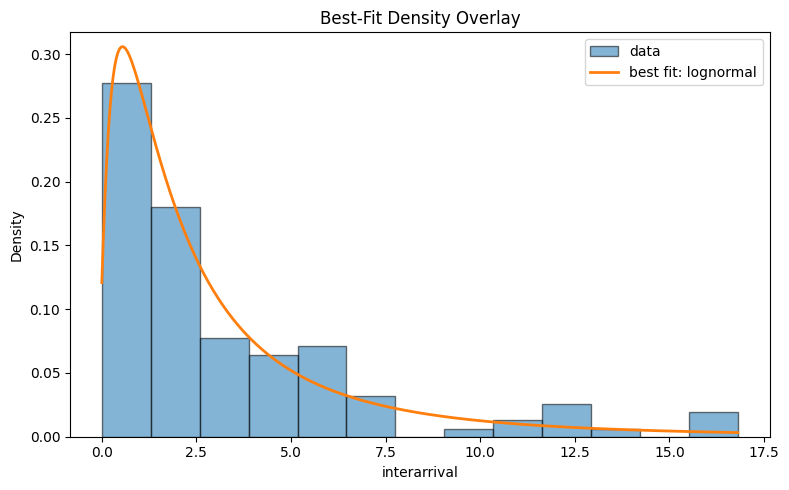

Best distribution: lognormal
Parameters: (np.float64(1.049248117046887), -0.1711039651083848, np.float64(2.1553828441809038))


In [25]:
best = fits.iloc[0]
best_name = best["distribution"]
best_params = best["params"]
best_dist = continuous_dists[best_name]

grid = np.linspace(np.min(x), np.max(x), 400)

plt.figure(figsize=(8, 5))
plt.hist(x, bins="auto", density=True, alpha=0.55, edgecolor="black", label="data")
plt.plot(grid, best_dist.pdf(grid, *best_params), linewidth=2, label=f"best fit: {best_name}")
plt.title("Best-Fit Density Overlay")
plt.xlabel(COLUMN)
plt.ylabel("Density")
plt.ylim(0, np.percentile(best_dist.pdf(grid, *best_params), 95) * 1.2)
plt.legend()
plt.tight_layout()
plt.show()

print("Best distribution:", best_name)
print("Parameters:", best_params)

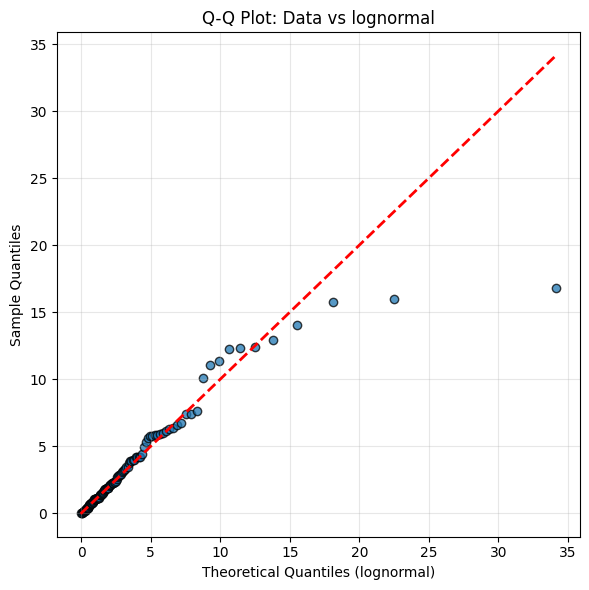

In [26]:
# Q-Q Plot for the best-fit distribution

best = fits.iloc[0]
best_name = best["distribution"]
best_params = best["params"]
best_dist = continuous_dists[best_name]

x_sorted = np.sort(x)
n = len(x_sorted)

# plotting positions: 1/(n+1), 2/(n+1), ..., n/(n+1)
probabilities = (np.arange(1, n + 1) - 0.5) / n

theoretical_quantiles = best_dist.ppf(probabilities, *best_params)
sample_quantiles = x_sorted

plt.figure(figsize=(6, 6))
plt.scatter(theoretical_quantiles, sample_quantiles, alpha=0.75, edgecolor="black")

min_q = min(np.min(theoretical_quantiles), np.min(sample_quantiles))
max_q = max(np.max(theoretical_quantiles), np.max(sample_quantiles))

plt.plot([min_q, max_q], [min_q, max_q], color="red", linestyle="--", linewidth=2)

plt.title(f"Q-Q Plot: Data vs {best_name}")
plt.xlabel(f"Theoretical Quantiles ({best_name})")
plt.ylabel("Sample Quantiles")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

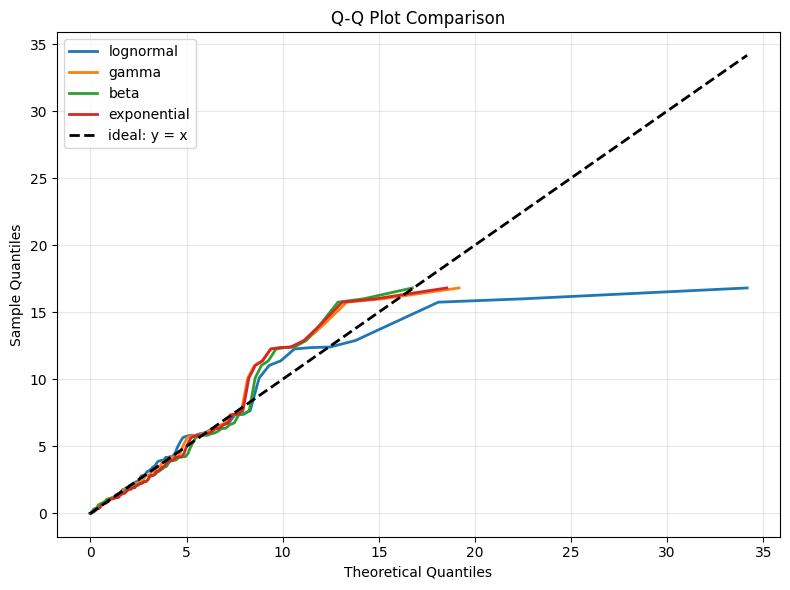

In [27]:
# Multiple Q-Q curves in one plot

top_k = 4
top_fits = fits.head(top_k)

x_sorted = np.sort(x)
n = len(x_sorted)
probabilities = (np.arange(1, n + 1) - 0.5) / n

plt.figure(figsize=(8, 6))

all_min = np.min(x_sorted)
all_max = np.max(x_sorted)

for _, row in top_fits.iterrows():
    dist_name = row["distribution"]

    if dist_name not in continuous_dists:
        continue

    dist = continuous_dists[dist_name]
    params = row["params"]

    theoretical_quantiles = dist.ppf(probabilities, *params)
    sample_quantiles = x_sorted

    valid = np.isfinite(theoretical_quantiles) & np.isfinite(sample_quantiles)

    theoretical_quantiles = theoretical_quantiles[valid]
    sample_quantiles = sample_quantiles[valid]

    order = np.argsort(theoretical_quantiles)
    theoretical_quantiles = theoretical_quantiles[order]
    sample_quantiles = sample_quantiles[order]

    plt.plot(
        theoretical_quantiles,
        sample_quantiles,
        linewidth=2,
        label=f"{dist_name}"
    )

    all_min = min(all_min, np.min(theoretical_quantiles), np.min(sample_quantiles))
    all_max = max(all_max, np.max(theoretical_quantiles), np.max(sample_quantiles))

plt.plot(
    [all_min, all_max],
    [all_min, all_max],
    color="black",
    linestyle="--",
    linewidth=2,
    label="ideal: y = x"
)

plt.title("Q-Q Plot Comparison")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Output Analysis - 독립 반복 CI

In [28]:
y = x.copy()

n = len(y)
mean_y = np.mean(y)
std_y = np.std(y, ddof=1)

alpha = 1 - CONFIDENCE
t_value = stats.t.ppf(1 - alpha / 2, df=n - 1)
half_width = t_value * std_y / math.sqrt(n)

ci_result = pd.Series({
    "n": n,
    "mean": mean_y,
    "std": std_y,
    "confidence": CONFIDENCE,
    "t_value": t_value,
    "half_width": half_width,
    "lower": mean_y - half_width,
    "upper": mean_y + half_width,
})

display(ci_result.to_frame("value"))

,value
n,120.000000
mean,3.382686
std,3.722614
confidence,0.950000
t_value,1.980100
half_width,0.672891
lower,2.709795
upper,4.055576


# Sequential Replication Rule

In [29]:
ABSOLUTE_ERROR = None
RELATIVE_ERROR = 0.05

if ABSOLUTE_ERROR is None:
    target_error = abs(mean_y) * RELATIVE_ERROR
else:
    target_error = ABSOLUTE_ERROR

z_value = stats.norm.ppf(1 - alpha / 2)
required_n = math.ceil((z_value * std_y / target_error) ** 2)
additional_replications = max(0, required_n - n)

sequential_result = pd.Series({
    "current_n": n,
    "current_mean": mean_y,
    "current_std": std_y,
    "target_error": target_error,
    "required_n_approx": required_n,
    "additional_replications": additional_replications,
})

display(sequential_result.to_frame("value"))

,value
current_n,120.000000
current_mean,3.382686
current_std,3.722614
target_error,0.169134
required_n_approx,1861.000000
additional_replications,1741.000000


# Paired Comparison

In [30]:
# 같은 random number stream으로 두 시스템을 비교할 때 사용
# compare.csv 안에 system_a, system_b 컬럼이 있다고 가정

COMPARE_FILE = "compare.csv"
A_COL = "system_a"
B_COL = "system_b"

if os.path.exists(COMPARE_FILE):
    compare_df = pd.read_csv(COMPARE_FILE)

    a = compare_df[A_COL].dropna().astype(float).to_numpy()
    b = compare_df[B_COL].dropna().astype(float).to_numpy()

    n_pair = min(len(a), len(b))
    d = a[:n_pair] - b[:n_pair]

    mean_d = np.mean(d)
    std_d = np.std(d, ddof=1)
    t_d = stats.t.ppf(1 - alpha / 2, df=n_pair - 1)
    hw_d = t_d * std_d / math.sqrt(n_pair)

    paired_result = pd.Series({
        "n_pairs": n_pair,
        "mean_A_minus_B": mean_d,
        "std_difference": std_d,
        "half_width": hw_d,
        "lower": mean_d - hw_d,
        "upper": mean_d + hw_d,
    })

    display(paired_result.to_frame("value"))
else:
    print("COMPARE_FILE이 없어서 paired comparison은 건너뜁니다.")

,value
n_pairs,40.000000
mean_A_minus_B,0.834473
std_difference,0.473664
half_width,0.151485
lower,0.682988
upper,0.985957


# SMORE Plot

In [31]:
# Cell 12: SMORE Plot for Comparing Systems
# compare.csv 안의 system_a, system_b 결과를 한 그래프에서 비교

SMORE_FILE = "compare.csv"
SYSTEM_COLUMNS = ["system_a", "system_b"]

smore_df = pd.read_csv(SMORE_FILE)

smore_rows = []

for col in SYSTEM_COLUMNS:
    values = smore_df[col].dropna().astype(float).to_numpy()
    
    n_smore = len(values)
    mean_smore = np.mean(values)
    std_smore = np.std(values, ddof=1)
    
    alpha_smore = 1 - CONFIDENCE
    t_smore = stats.t.ppf(1 - alpha_smore / 2, df=n_smore - 1)
    half_width_smore = t_smore * std_smore / np.sqrt(n_smore)
    
    smore_rows.append({
        "system": col,
        "n": n_smore,
        "min": np.min(values),
        "q1": np.quantile(values, 0.25),
        "median": np.median(values),
        "q3": np.quantile(values, 0.75),
        "max": np.max(values),
        "mean": mean_smore,
        "ci_lower": mean_smore - half_width_smore,
        "ci_upper": mean_smore + half_width_smore,
        "half_width": half_width_smore,
    })

smore_summary = pd.DataFrame(smore_rows)

display(smore_summary)

,system,n,min,q1,median,q3,max,mean,ci_lower,ci_upper,half_width
0,system_a,40,4.9326,7.670725,8.32375,9.83925,11.628,8.516443,8.000475,9.032410,0.515968
1,system_b,40,4.8860,6.509575,7.63305,8.79055,11.589,7.681970,7.156735,8.207205,0.525235


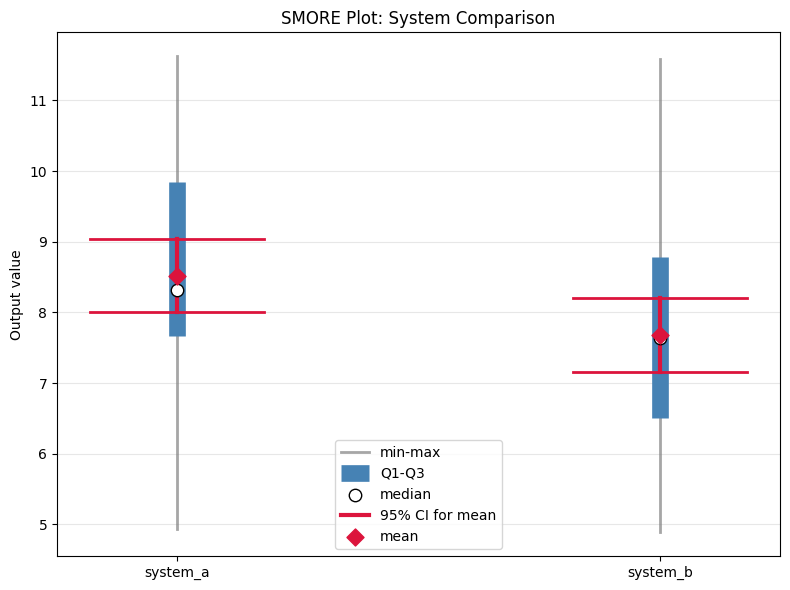

In [32]:
# Cell 13: Draw SMORE Plot

plt.figure(figsize=(8, 6))

x_positions = np.arange(len(smore_summary))

for i, row in smore_summary.iterrows():
    x_pos = x_positions[i]
    
    # min-max range
    plt.plot(
        [x_pos, x_pos],
        [row["min"], row["max"]],
        color="gray",
        linewidth=2,
        alpha=0.7,
        label="min-max" if i == 0 else None,
    )
    
    # interquartile range: Q1-Q3
    plt.plot(
        [x_pos, x_pos],
        [row["q1"], row["q3"]],
        color="steelblue",
        linewidth=12,
        solid_capstyle="butt",
        label="Q1-Q3" if i == 0 else None,
    )
    
    # median
    plt.scatter(
        x_pos,
        row["median"],
        color="white",
        edgecolor="black",
        s=80,
        zorder=4,
        label="median" if i == 0 else None,
    )
    
    # confidence interval for mean
    plt.plot(
        [x_pos, x_pos],
        [row["ci_lower"], row["ci_upper"]],
        color="crimson",
        linewidth=3,
        label=f"{int(CONFIDENCE * 100)}% CI for mean" if i == 0 else None,
    )
    
    # caps for confidence interval
    plt.plot(
        [x_pos - 0.18, x_pos + 0.18],
        [row["ci_lower"], row["ci_lower"]],
        color="crimson",
        linewidth=2,
    )
    plt.plot(
        [x_pos - 0.18, x_pos + 0.18],
        [row["ci_upper"], row["ci_upper"]],
        color="crimson",
        linewidth=2,
    )
    
    # mean
    plt.scatter(
        x_pos,
        row["mean"],
        color="crimson",
        marker="D",
        s=75,
        zorder=5,
        label="mean" if i == 0 else None,
    )

plt.xticks(x_positions, smore_summary["system"])
plt.ylabel("Output value")
plt.title("SMORE Plot: System Comparison")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 서로 다른 분포를 채택했을 때(real data, fitted beta, fitted exponential, min-max uniform)

,scenario,n,mean,std,variance,min,q05,q25,median,q75,q95,max,skewness,kurtosis_excess,ks_statistic_vs_original,ks_pvalue_vs_original,mean_difference_from_original,std_difference_from_original
0,original_service_time,120,3.382686,3.722614,13.857852,0.000400,0.157545,0.967350,1.984300,4.224825,12.360315,16.808600,1.860950,3.162376,0.000000,1.000000e+00,0.000000,0.000000
1,fitted_beta,120,3.765870,3.689720,13.614035,0.004087,0.139070,1.252586,2.730961,5.092031,10.424909,20.267766,1.817434,4.273116,0.166667,7.123409e-02,0.383185,-0.032893
2,fitted_exponential,120,4.362360,4.126260,17.026026,0.160527,0.569315,1.364664,3.040574,5.698624,12.042748,20.303289,1.754210,3.243493,0.175000,5.052187e-02,0.979674,0.403647
3,minmax_uniform,120,9.166539,4.997629,24.976299,0.024174,1.035053,4.971901,9.656362,13.425720,16.097949,16.804958,-0.252158,-1.124518,0.575000,1.132495e-18,5.783854,1.275016


,scenario,distribution,params
0,original_service_time,empirical,use your_data.csv service_time values directly
1,fitted_beta,beta,"(0.7672321397095101, 6.054567899054465, 0.0003..."
2,fitted_exponential,exponential,"(0.0004, 3.382285833333333)"
3,minmax_uniform,uniform,"(0.0004, 16.8086)"


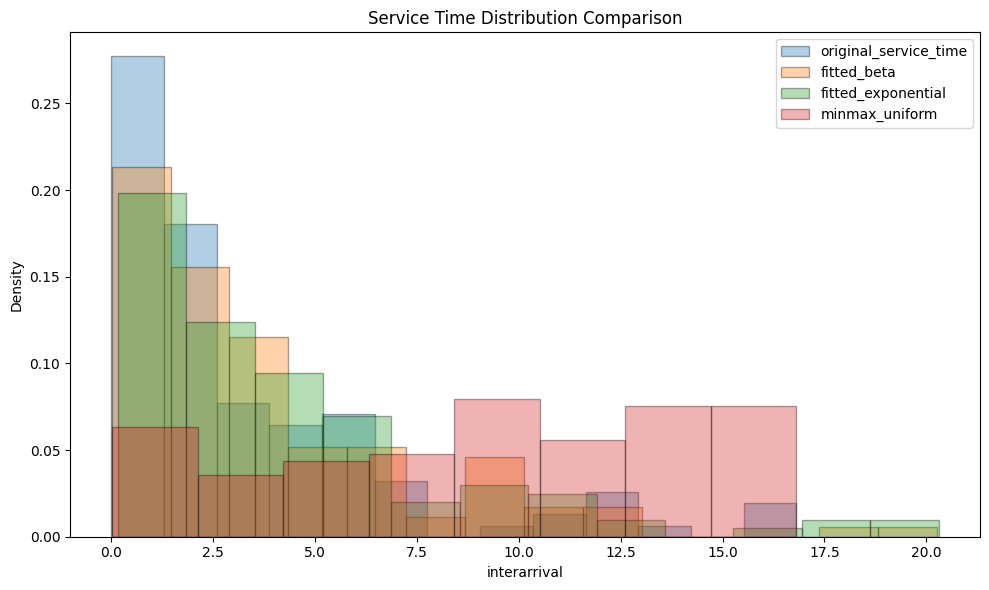

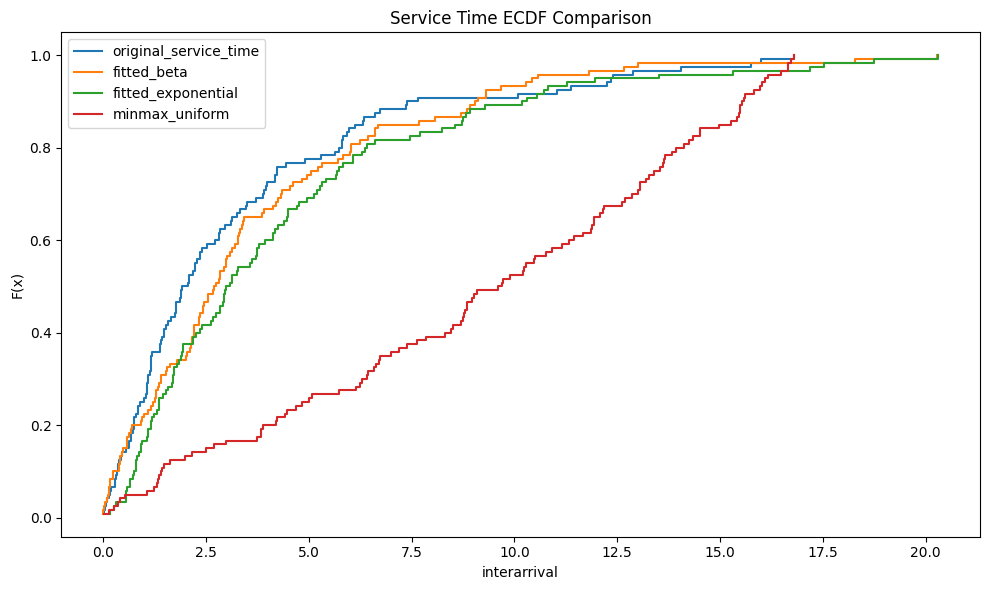

/var/folders/bq/l0xgqt317fgc3732g89jyrrw0000gn/T/ipykernel_83256/669519873.py:163: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


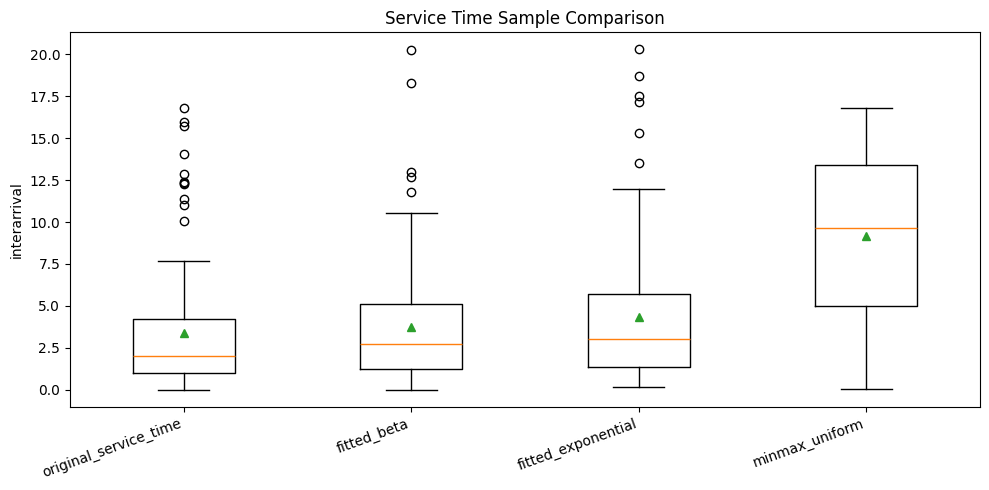

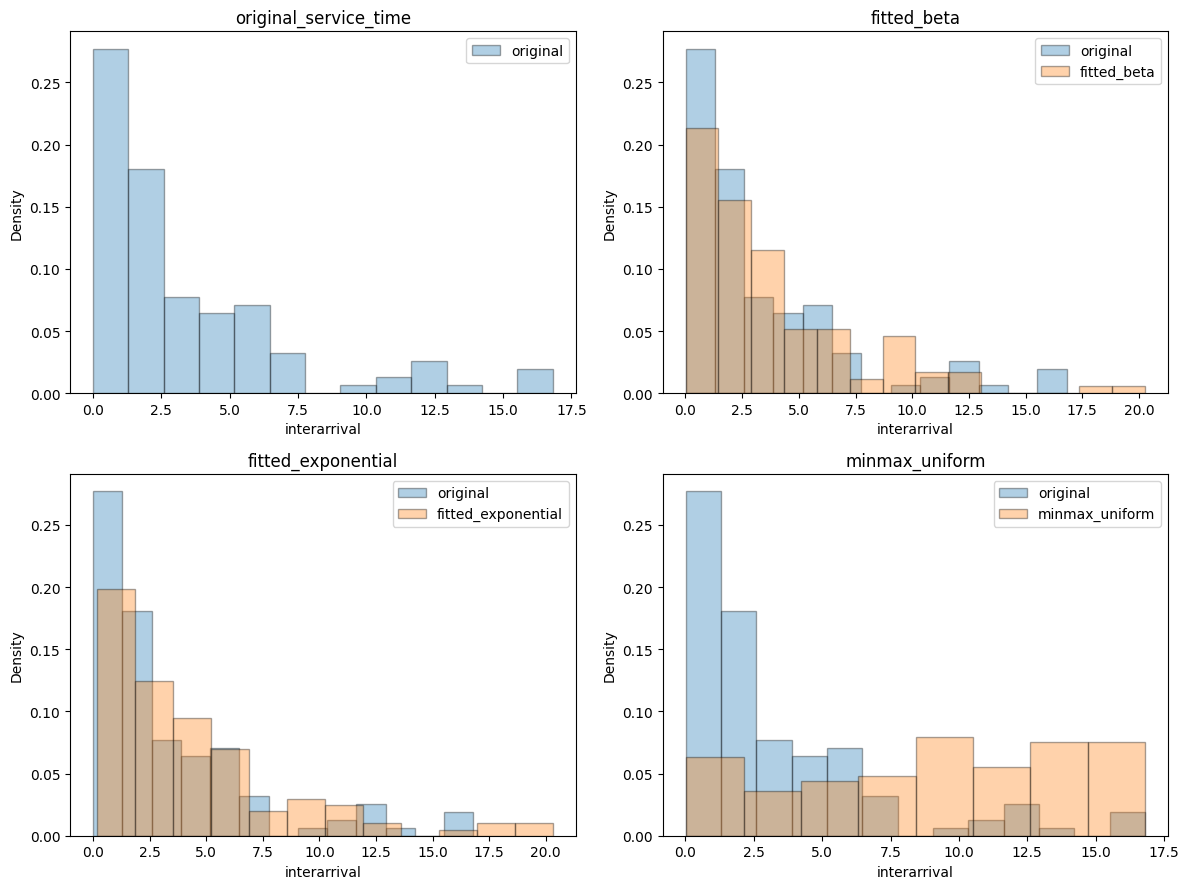

Saved: analysis_results/service_time_input_modeling_comparison.csv


In [33]:
# service_time input modeling comparison
# 1) original service_time 그대로 사용
# 2) fitted beta distribution에서 service_time 생성
# 3) fitted exponential distribution에서 service_time 생성
# 4) original service_time의 min-max uniform distribution에서 service_time 생성

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

n_compare = len(x)
service_time_original = x.copy()

beta_params = fits.loc[fits["distribution"] == "beta", "params"].iloc[0]
exponential_params = fits.loc[fits["distribution"] == "exponential", "params"].iloc[0]

# params가 CSV에서 문자열로 다시 읽힌 경우까지 대비한다.
# 현재 노트북을 위에서부터 실행했다면 보통 tuple 형태로 들어 있다.
if isinstance(beta_params, str):
    beta_params = tuple(
        float(v.strip().replace("np.float64(", "").replace(")", ""))
        for v in beta_params.strip("()").split(",")
        if v.strip()
    )

if isinstance(exponential_params, str):
    exponential_params = tuple(
        float(v.strip().replace("np.float64(", "").replace(")", ""))
        for v in exponential_params.strip("()").split(",")
        if v.strip()
    )

service_time_beta = continuous_dists["beta"].rvs(
    *beta_params,
    size=n_compare,
    random_state=rng
)

service_time_exponential = continuous_dists["exponential"].rvs(
    *exponential_params,
    size=n_compare,
    random_state=rng
)

service_time_uniform_minmax = rng.uniform(
    low=np.min(service_time_original),
    high=np.max(service_time_original),
    size=n_compare,
)

comparison_samples = {
    "original_service_time": service_time_original,
    "fitted_beta": service_time_beta,
    "fitted_exponential": service_time_exponential,
    "minmax_uniform": service_time_uniform_minmax,
}

comparison_rows = []

for scenario, values in comparison_samples.items():
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if scenario == "original_service_time":
        ks_stat, ks_p = 0.0, 1.0
    else:
        ks_stat, ks_p = stats.ks_2samp(service_time_original, values)

    comparison_rows.append({
        "scenario": scenario,
        "n": len(values),
        "mean": np.mean(values),
        "std": np.std(values, ddof=1),
        "variance": np.var(values, ddof=1),
        "min": np.min(values),
        "q05": np.quantile(values, 0.05),
        "q25": np.quantile(values, 0.25),
        "median": np.median(values),
        "q75": np.quantile(values, 0.75),
        "q95": np.quantile(values, 0.95),
        "max": np.max(values),
        "skewness": stats.skew(values, bias=False),
        "kurtosis_excess": stats.kurtosis(values, bias=False),
        "ks_statistic_vs_original": ks_stat,
        "ks_pvalue_vs_original": ks_p,
        "mean_difference_from_original": np.mean(values) - np.mean(service_time_original),
        "std_difference_from_original": np.std(values, ddof=1) - np.std(service_time_original, ddof=1),
    })

service_time_comparison = pd.DataFrame(comparison_rows)
display(service_time_comparison)

service_time_comparison.to_csv(
    os.path.join(OUTDIR, "service_time_input_modeling_comparison.csv"),
    index=False,
)

parameter_comparison = pd.DataFrame([
    {
        "scenario": "original_service_time",
        "distribution": "empirical",
        "params": "use your_data.csv service_time values directly",
    },
    {
        "scenario": "fitted_beta",
        "distribution": "beta",
        "params": beta_params,
    },
    {
        "scenario": "fitted_exponential",
        "distribution": "exponential",
        "params": exponential_params,
    },
    {
        "scenario": "minmax_uniform",
        "distribution": "uniform",
        "params": (np.min(service_time_original), np.max(service_time_original)),
    },
])

display(parameter_comparison)

plt.figure(figsize=(10, 6))

for scenario, values in comparison_samples.items():
    plt.hist(
        values,
        bins="auto",
        density=True,
        alpha=0.35,
        edgecolor="black",
        label=scenario,
    )

plt.title("Service Time Distribution Comparison")
plt.xlabel(COLUMN)
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

for scenario, values in comparison_samples.items():
    sorted_values = np.sort(values)
    probabilities = np.arange(1, len(sorted_values) + 1) / len(sorted_values)

    plt.step(
        sorted_values,
        probabilities,
        where="post",
        label=scenario
    )

plt.title("Service Time ECDF Comparison")
plt.xlabel(COLUMN)
plt.ylabel("F(x)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

plt.boxplot(
    [comparison_samples[name] for name in comparison_samples.keys()],
    labels=list(comparison_samples.keys()),
    showmeans=True,
)

plt.title("Service Time Sample Comparison")
plt.ylabel(COLUMN)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, (scenario, values) in zip(axes, comparison_samples.items()):
    ax.hist(
        service_time_original,
        bins="auto",
        density=True,
        alpha=0.35,
        label="original",
        edgecolor="black"
    )

    if scenario != "original_service_time":
        ax.hist(
            values,
            bins="auto",
            density=True,
            alpha=0.35,
            label=scenario,
            edgecolor="black"
        )

    ax.set_title(scenario)
    ax.set_xlabel(COLUMN)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

print("Saved:", os.path.join(OUTDIR, "service_time_input_modeling_comparison.csv"))

# 서로 다른 분포를 input data로 사용하였을 때 output의 차이
arrival rate은 고정되고 service rate은 위의 분포들을 사용하였으며, 각각 100번씩 실행하였습니다.

Fixed arrival rate: 0.095187102147659
Mean interarrival time: 10.505624999999998


,scenario,replication,average_waiting_time,median_waiting_time,average_time_in_system,median_time_in_system,average_service_time,utilization,throughput,max_queue_length
0,real_service_time,1,1.463587,0.0,4.657717,3.115900,3.194131,0.277330,0.086825,4
1,real_service_time,2,1.610960,0.0,5.073771,2.850700,3.462811,0.289014,0.083462,4
2,real_service_time,3,1.536077,0.0,4.792224,2.522283,3.256146,0.324855,0.099767,4
3,real_service_time,4,1.710235,0.0,5.206653,3.717100,3.496418,0.338903,0.096929,5
4,real_service_time,5,1.810169,0.0,5.172336,3.705471,3.362168,0.330904,0.098420,5


,scenario,replications,avg_waiting_time,avg_time_in_system,avg_service_time,avg_utilization,avg_throughput,avg_max_queue_length
0,fitted_beta,100,1.562962,4.910553,3.347590,0.317554,0.094843,4.22
1,fitted_exponential,100,1.606622,4.976649,3.370027,0.321719,0.095461,4.27
2,minmax_uniform,100,20.667402,29.062676,8.395274,0.796077,0.094840,10.28
3,real_service_time,100,1.705860,5.040733,3.334873,0.319189,0.095686,4.66


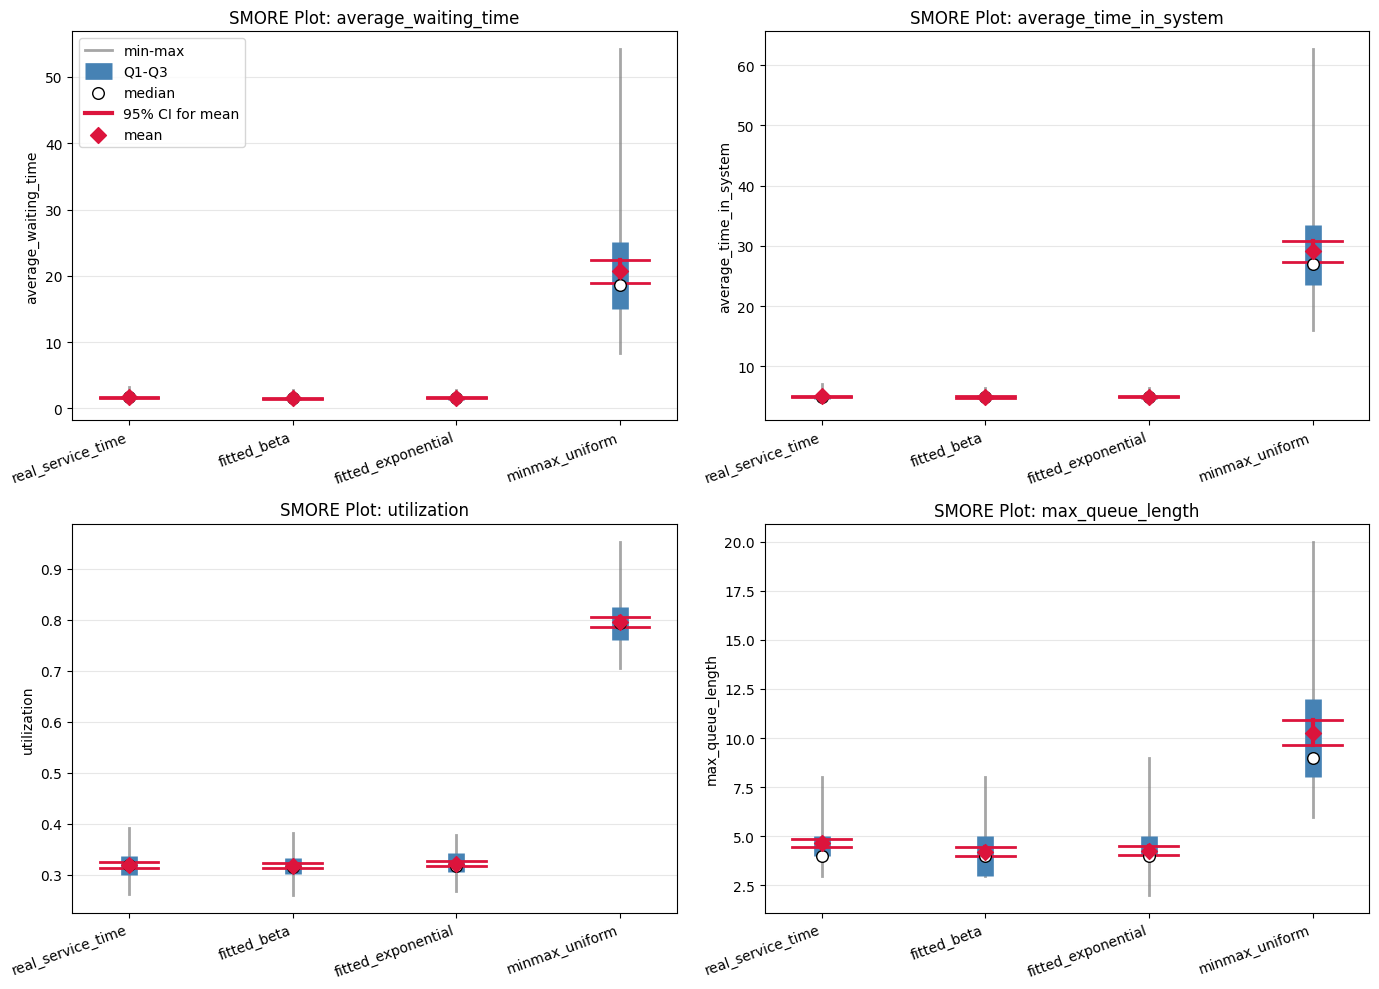

Saved: analysis_results/queue_output_comparison_by_service_time_model.csv


In [34]:
# Simple queueing simulation output comparison
# Service time scenarios:
# 1) real service_time data sampled with replacement
# 2) fitted beta
# 3) fitted exponential
# 4) min-max uniform
#
# Queue model:
# - Single server
# - FCFS
# - Interarrival time ~ Exponential(fixed arrival rate)
# - Compare output metrics with SMORE plots

N_REPLICATIONS = 100
N_CUSTOMERS = 300
RANDOM_SEED = 2026

rng = np.random.default_rng(RANDOM_SEED)

service_time_original = x.copy()
service_time_original = service_time_original[np.isfinite(service_time_original)]

beta_params = fits.loc[fits["distribution"] == "beta", "params"].iloc[0]
exponential_params = fits.loc[fits["distribution"] == "exponential", "params"].iloc[0]

if isinstance(beta_params, str):
    beta_params = tuple(
        float(v.strip().replace("np.float64(", "").replace(")", ""))
        for v in beta_params.strip("()").split(",")
        if v.strip()
    )

if isinstance(exponential_params, str):
    exponential_params = tuple(
        float(v.strip().replace("np.float64(", "").replace(")", ""))
        for v in exponential_params.strip("()").split(",")
        if v.strip()
    )

# arrival rate은 모든 scenario에 똑같이 적용한다.
# min-max uniform이 평균 service time이 가장 클 수 있으므로,
# 전체 scenario가 너무 불안정해지지 않게 느린 scenario 기준 utilization 약 80%로 설정한다.
mean_service_real = np.mean(service_time_original)
mean_service_beta = continuous_dists["beta"].mean(*beta_params)
mean_service_exponential = continuous_dists["exponential"].mean(*exponential_params)
mean_service_uniform = (np.min(service_time_original) + np.max(service_time_original)) / 2

max_mean_service = max(
    mean_service_real,
    mean_service_beta,
    mean_service_exponential,
    mean_service_uniform
)

TARGET_UTILIZATION_FOR_SLOWEST_SCENARIO = 0.80
ARRIVAL_RATE = TARGET_UTILIZATION_FOR_SLOWEST_SCENARIO / max_mean_service

print("Fixed arrival rate:", ARRIVAL_RATE)
print("Mean interarrival time:", 1 / ARRIVAL_RATE)

queue_output_rows = []

for scenario in [
    "real_service_time",
    "fitted_beta",
    "fitted_exponential",
    "minmax_uniform",
]:
    for replication in range(1, N_REPLICATIONS + 1):

        interarrival_time = rng.exponential(
            scale=1 / ARRIVAL_RATE,
            size=N_CUSTOMERS
        )

        arrival_time = np.cumsum(interarrival_time)

        if scenario == "real_service_time":
            service_time = rng.choice(
                service_time_original,
                size=N_CUSTOMERS,
                replace=True
            )

        elif scenario == "fitted_beta":
            service_time = continuous_dists["beta"].rvs(
                *beta_params,
                size=N_CUSTOMERS,
                random_state=rng
            )

        elif scenario == "fitted_exponential":
            service_time = continuous_dists["exponential"].rvs(
                *exponential_params,
                size=N_CUSTOMERS,
                random_state=rng
            )

        else:
            service_time = rng.uniform(
                low=np.min(service_time_original),
                high=np.max(service_time_original),
                size=N_CUSTOMERS
            )

        service_time = np.maximum(service_time, 0)

        start_time = np.zeros(N_CUSTOMERS)
        completion_time = np.zeros(N_CUSTOMERS)
        waiting_time = np.zeros(N_CUSTOMERS)
        time_in_system = np.zeros(N_CUSTOMERS)

        for i in range(N_CUSTOMERS):
            if i == 0:
                start_time[i] = arrival_time[i]
            else:
                start_time[i] = max(arrival_time[i], completion_time[i - 1])

            completion_time[i] = start_time[i] + service_time[i]
            waiting_time[i] = start_time[i] - arrival_time[i]
            time_in_system[i] = completion_time[i] - arrival_time[i]

        total_time = completion_time[-1] - arrival_time[0]
        busy_time = np.sum(service_time)
        utilization = busy_time / total_time
        throughput = N_CUSTOMERS / total_time

        max_queue_length = 0

        for t in arrival_time:
            queue_length_at_t = np.sum(
                (arrival_time <= t) &
                (start_time > t)
            )

            if queue_length_at_t > max_queue_length:
                max_queue_length = queue_length_at_t

        queue_output_rows.append({
            "scenario": scenario,
            "replication": replication,
            "average_waiting_time": np.mean(waiting_time),
            "median_waiting_time": np.median(waiting_time),
            "average_time_in_system": np.mean(time_in_system),
            "median_time_in_system": np.median(time_in_system),
            "average_service_time": np.mean(service_time),
            "utilization": utilization,
            "throughput": throughput,
            "max_queue_length": max_queue_length,
        })

queue_output_df = pd.DataFrame(queue_output_rows)

display(queue_output_df.head())
display(queue_output_df.groupby("scenario").agg(
    replications=("replication", "count"),
    avg_waiting_time=("average_waiting_time", "mean"),
    avg_time_in_system=("average_time_in_system", "mean"),
    avg_service_time=("average_service_time", "mean"),
    avg_utilization=("utilization", "mean"),
    avg_throughput=("throughput", "mean"),
    avg_max_queue_length=("max_queue_length", "mean"),
).reset_index())

queue_output_df.to_csv(
    os.path.join(OUTDIR, "queue_output_comparison_by_service_time_model.csv"),
    index=False
)

SMORE_METRICS = [
    "average_waiting_time",
    "average_time_in_system",
    "utilization",
    "max_queue_length",
]

scenario_order = [
    "real_service_time",
    "fitted_beta",
    "fitted_exponential",
    "minmax_uniform",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, metric in zip(axes, SMORE_METRICS):

    smore_rows = []

    for scenario in scenario_order:
        values = queue_output_df.loc[
            queue_output_df["scenario"] == scenario,
            metric
        ].dropna().astype(float).to_numpy()

        n_smore = len(values)
        mean_smore = np.mean(values)
        std_smore = np.std(values, ddof=1)

        alpha_smore = 1 - CONFIDENCE
        t_smore = stats.t.ppf(1 - alpha_smore / 2, df=n_smore - 1)
        half_width_smore = t_smore * std_smore / np.sqrt(n_smore)

        smore_rows.append({
            "scenario": scenario,
            "n": n_smore,
            "min": np.min(values),
            "q1": np.quantile(values, 0.25),
            "median": np.median(values),
            "q3": np.quantile(values, 0.75),
            "max": np.max(values),
            "mean": mean_smore,
            "ci_lower": mean_smore - half_width_smore,
            "ci_upper": mean_smore + half_width_smore,
            "half_width": half_width_smore,
        })

    smore_summary = pd.DataFrame(smore_rows)
    x_positions = np.arange(len(smore_summary))

    for i, row in smore_summary.iterrows():
        x_pos = x_positions[i]

        ax.plot(
            [x_pos, x_pos],
            [row["min"], row["max"]],
            color="gray",
            linewidth=2,
            alpha=0.7,
            label="min-max" if i == 0 else None,
        )

        ax.plot(
            [x_pos, x_pos],
            [row["q1"], row["q3"]],
            color="steelblue",
            linewidth=12,
            solid_capstyle="butt",
            label="Q1-Q3" if i == 0 else None,
        )

        ax.scatter(
            x_pos,
            row["median"],
            color="white",
            edgecolor="black",
            s=70,
            zorder=4,
            label="median" if i == 0 else None,
        )

        ax.plot(
            [x_pos, x_pos],
            [row["ci_lower"], row["ci_upper"]],
            color="crimson",
            linewidth=3,
            label=f"{int(CONFIDENCE * 100)}% CI for mean" if i == 0 else None,
        )

        ax.plot(
            [x_pos - 0.18, x_pos + 0.18],
            [row["ci_lower"], row["ci_lower"]],
            color="crimson",
            linewidth=2,
        )

        ax.plot(
            [x_pos - 0.18, x_pos + 0.18],
            [row["ci_upper"], row["ci_upper"]],
            color="crimson",
            linewidth=2,
        )

        ax.scatter(
            x_pos,
            row["mean"],
            color="crimson",
            marker="D",
            s=65,
            zorder=5,
            label="mean" if i == 0 else None,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(smore_summary["scenario"], rotation=20, ha="right")
    ax.set_title(f"SMORE Plot: {metric}")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.3)

axes[0].legend(loc="best")
plt.tight_layout()
plt.show()

print("Saved:", os.path.join(OUTDIR, "queue_output_comparison_by_service_time_model.csv"))

# 데이터 수에 따른 차이

/Users/joramee/miniforge3/envs/py313/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)


,scenario,n,mean,std,variance,min,q05,q25,median,q75,q95,max,skewness,kurtosis_excess,ks_statistic_vs_actual,ks_pvalue_vs_actual,mean_difference_from_actual,std_difference_from_actual
0,actual_service_time,120,3.382686,3.722614,13.857852,0.000400,0.157545,0.967350,1.984300,4.224825,12.360315,16.808600,1.860950,3.162376,0.000000,1.000000,0.000000,0.000000
1,beta_fit_using_10_data,120,3.094111,2.617346,6.850503,-0.540065,-0.469599,0.623344,2.573995,5.404776,7.183321,7.616191,0.230533,-1.318287,0.141667,0.180169,-0.288575,-1.105267
2,beta_fit_using_40_data,120,2.505329,2.273156,5.167240,0.001948,0.037010,0.709656,2.021537,3.349397,7.313028,10.321336,1.174343,0.947857,0.108333,0.483629,-0.877356,-1.449457
3,beta_fit_using_all_data,120,3.794292,3.756129,14.108502,0.015522,0.253159,0.895543,2.711288,5.343493,10.638117,20.886529,1.627908,3.450203,0.133333,0.237127,0.411606,0.033515


,scenario,distribution,fit_data_n,params
0,actual_service_time,empirical,120,use your_data.csv service_time values directly
1,beta_fit_using_10_data,beta,10,"(0.5878663607463981, 0.7271946525133028, -0.54..."
2,beta_fit_using_40_data,beta,40,"(0.8002388689320814, 3.761866875168601, 0.0003..."
3,beta_fit_using_all_data,beta,120,"(0.7672321397095101, 6.054567899054465, 0.0003..."


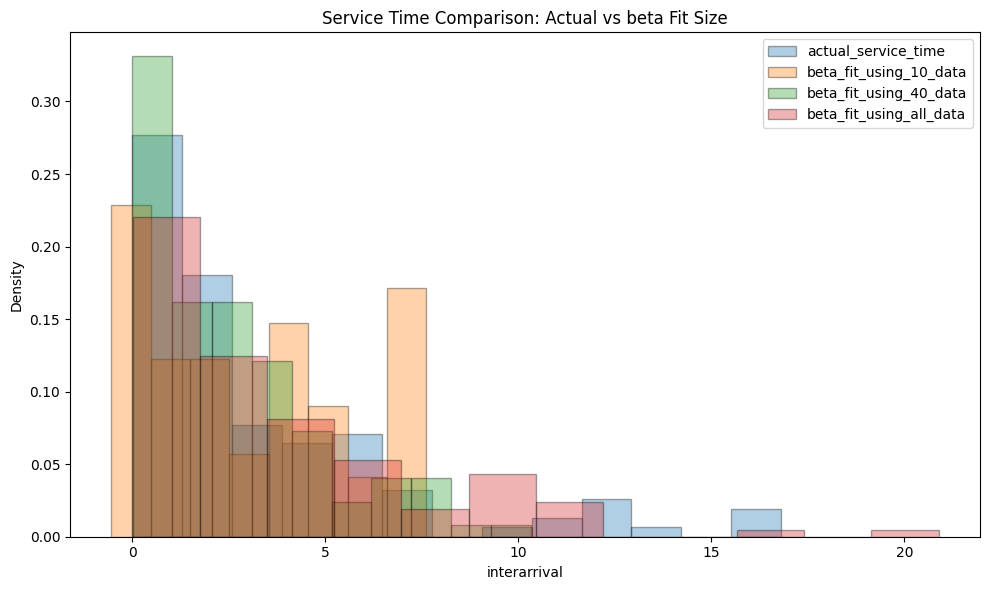

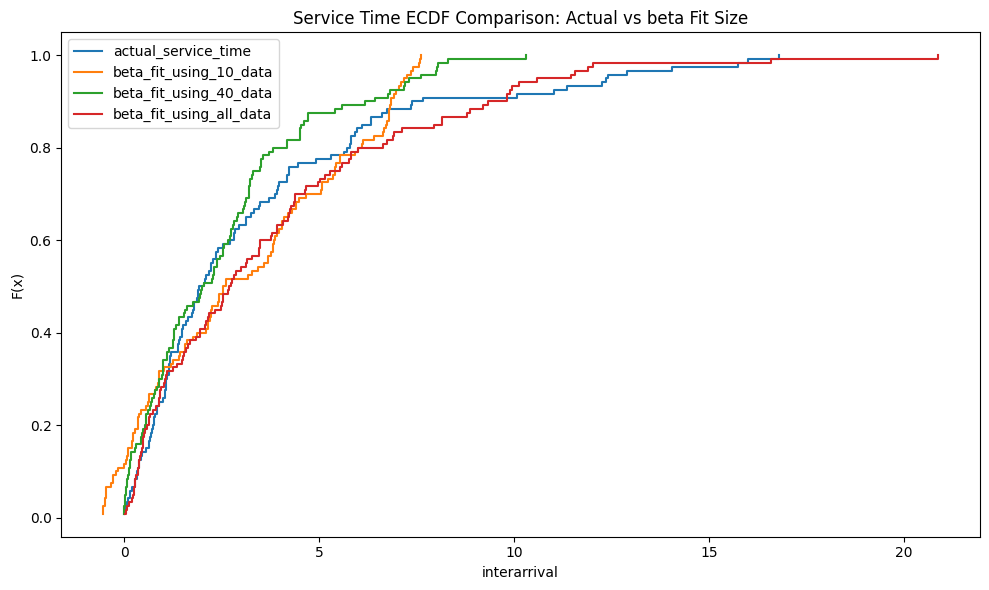

/var/folders/bq/l0xgqt317fgc3732g89jyrrw0000gn/T/ipykernel_83256/2744805105.py:164: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


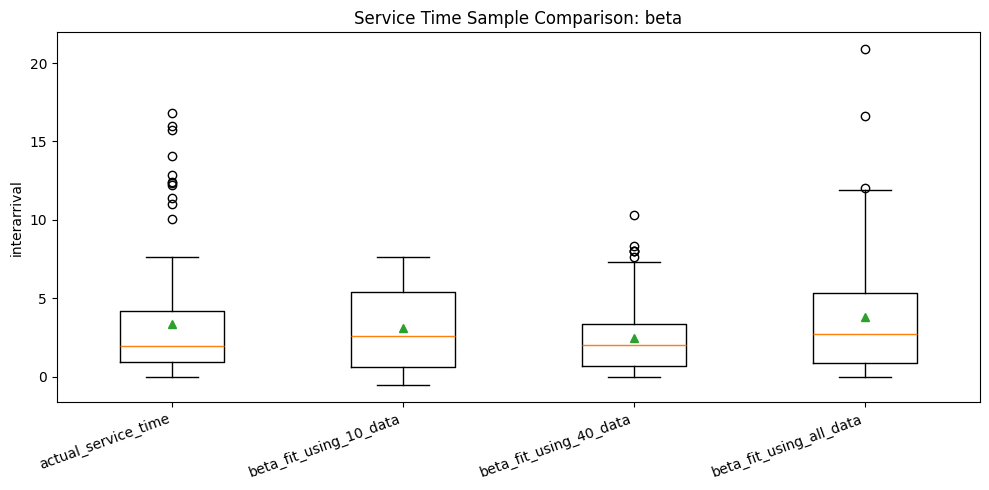

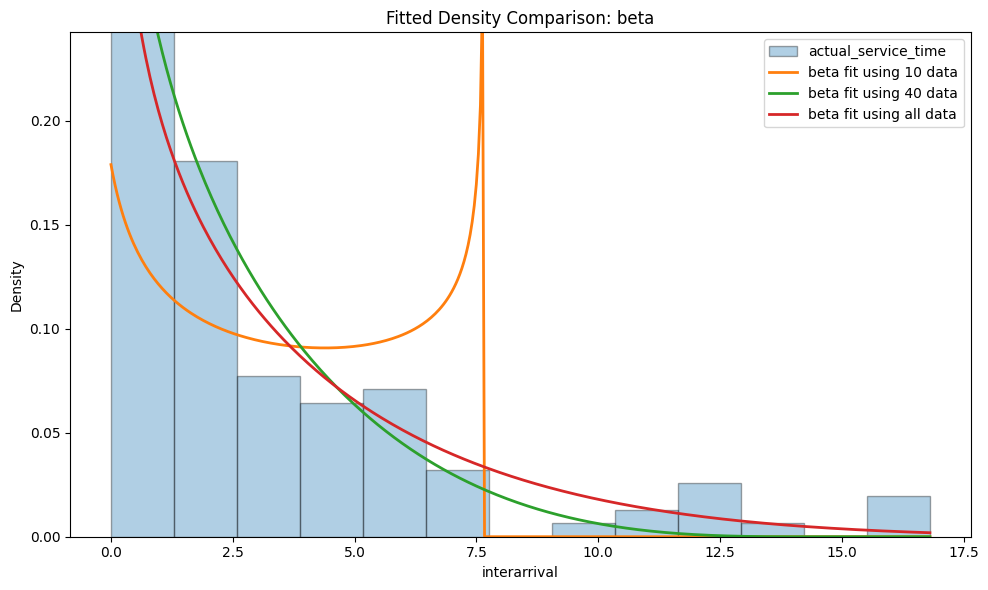

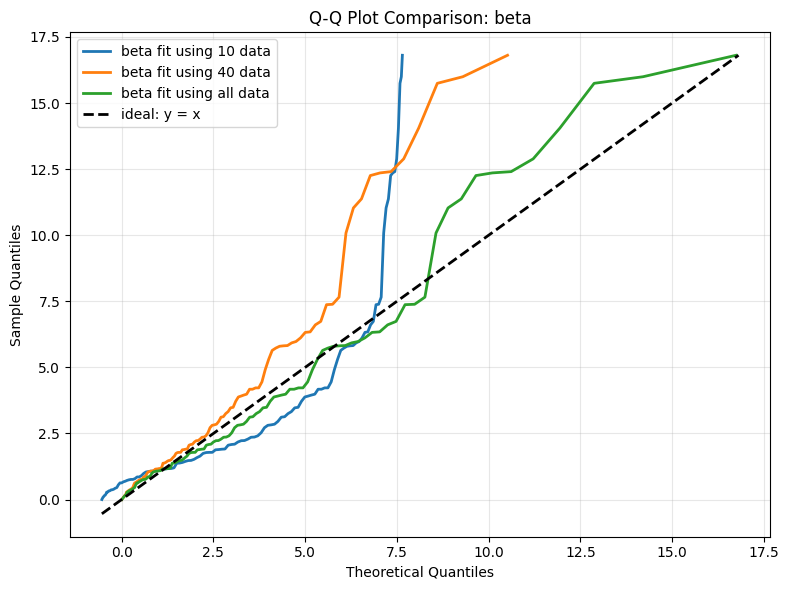

Saved: analysis_results/service_time_beta_fit_size_comparison.csv


In [35]:
# Compare fitting with 10 data points, 40 data points, and all available data
# 1) actual service_time
# 2) fitted distribution using 10 service_time values
# 3) fitted distribution using 40 service_time values
# 4) fitted distribution using all service_time values

FIT_DISTRIBUTION = "beta"   # 예: "beta", "exponential", "gamma", "lognormal", "weibull", "normal"
N_SMALL_FIT_1 = 10
N_SMALL_FIT_2 = 40
RANDOM_SEED = 2026

rng = np.random.default_rng(RANDOM_SEED)

service_time_original = x.copy()
service_time_original = service_time_original[np.isfinite(service_time_original)]

service_time_fit_10_data = service_time_original[:N_SMALL_FIT_1]
service_time_fit_40_data = service_time_original[:N_SMALL_FIT_2]
service_time_fit_all_data = service_time_original.copy()

fit_dist = continuous_dists[FIT_DISTRIBUTION]

params_10_data = fit_dist.fit(service_time_fit_10_data)
params_40_data = fit_dist.fit(service_time_fit_40_data)
params_all_data = fit_dist.fit(service_time_fit_all_data)

n_compare = len(service_time_original)

service_time_from_10_fit = fit_dist.rvs(
    *params_10_data,
    size=n_compare,
    random_state=rng
)

service_time_from_40_fit = fit_dist.rvs(
    *params_40_data,
    size=n_compare,
    random_state=rng
)

service_time_from_all_fit = fit_dist.rvs(
    *params_all_data,
    size=n_compare,
    random_state=rng
)

comparison_samples = {
    "actual_service_time": service_time_original,
    f"{FIT_DISTRIBUTION}_fit_using_10_data": service_time_from_10_fit,
    f"{FIT_DISTRIBUTION}_fit_using_40_data": service_time_from_40_fit,
    f"{FIT_DISTRIBUTION}_fit_using_all_data": service_time_from_all_fit,
}

comparison_rows = []

for scenario, values in comparison_samples.items():
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if scenario == "actual_service_time":
        ks_stat, ks_p = 0.0, 1.0
    else:
        ks_stat, ks_p = stats.ks_2samp(service_time_original, values)

    comparison_rows.append({
        "scenario": scenario,
        "n": len(values),
        "mean": np.mean(values),
        "std": np.std(values, ddof=1),
        "variance": np.var(values, ddof=1),
        "min": np.min(values),
        "q05": np.quantile(values, 0.05),
        "q25": np.quantile(values, 0.25),
        "median": np.median(values),
        "q75": np.quantile(values, 0.75),
        "q95": np.quantile(values, 0.95),
        "max": np.max(values),
        "skewness": stats.skew(values, bias=False),
        "kurtosis_excess": stats.kurtosis(values, bias=False),
        "ks_statistic_vs_actual": ks_stat,
        "ks_pvalue_vs_actual": ks_p,
        "mean_difference_from_actual": np.mean(values) - np.mean(service_time_original),
        "std_difference_from_actual": np.std(values, ddof=1) - np.std(service_time_original, ddof=1),
    })

fit_size_comparison = pd.DataFrame(comparison_rows)
display(fit_size_comparison)

fit_size_comparison.to_csv(
    os.path.join(OUTDIR, f"service_time_{FIT_DISTRIBUTION}_fit_size_comparison.csv"),
    index=False,
)

parameter_comparison = pd.DataFrame([
    {
        "scenario": "actual_service_time",
        "distribution": "empirical",
        "fit_data_n": len(service_time_original),
        "params": "use your_data.csv service_time values directly",
    },
    {
        "scenario": f"{FIT_DISTRIBUTION}_fit_using_10_data",
        "distribution": FIT_DISTRIBUTION,
        "fit_data_n": len(service_time_fit_10_data),
        "params": params_10_data,
    },
    {
        "scenario": f"{FIT_DISTRIBUTION}_fit_using_40_data",
        "distribution": FIT_DISTRIBUTION,
        "fit_data_n": len(service_time_fit_40_data),
        "params": params_40_data,
    },
    {
        "scenario": f"{FIT_DISTRIBUTION}_fit_using_all_data",
        "distribution": FIT_DISTRIBUTION,
        "fit_data_n": len(service_time_fit_all_data),
        "params": params_all_data,
    },
])

display(parameter_comparison)

plt.figure(figsize=(10, 6))

for scenario, values in comparison_samples.items():
    plt.hist(
        values,
        bins="auto",
        density=True,
        alpha=0.35,
        edgecolor="black",
        label=scenario,
    )

plt.title(f"Service Time Comparison: Actual vs {FIT_DISTRIBUTION} Fit Size")
plt.xlabel(COLUMN)
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

for scenario, values in comparison_samples.items():
    sorted_values = np.sort(values)
    probabilities = np.arange(1, len(sorted_values) + 1) / len(sorted_values)

    plt.step(
        sorted_values,
        probabilities,
        where="post",
        label=scenario
    )

plt.title(f"Service Time ECDF Comparison: Actual vs {FIT_DISTRIBUTION} Fit Size")
plt.xlabel(COLUMN)
plt.ylabel("F(x)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

plt.boxplot(
    [comparison_samples[name] for name in comparison_samples.keys()],
    labels=list(comparison_samples.keys()),
    showmeans=True,
)

plt.title(f"Service Time Sample Comparison: {FIT_DISTRIBUTION}")
plt.ylabel(COLUMN)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

grid = np.linspace(
    np.min(service_time_original),
    np.max(service_time_original),
    400
)

pdf_10_data = fit_dist.pdf(grid, *params_10_data)
pdf_40_data = fit_dist.pdf(grid, *params_40_data)
pdf_all_data = fit_dist.pdf(grid, *params_all_data)

plt.figure(figsize=(10, 6))

plt.hist(
    service_time_original,
    bins="auto",
    density=True,
    alpha=0.35,
    edgecolor="black",
    label="actual_service_time"
)

plt.plot(
    grid,
    pdf_10_data,
    linewidth=2,
    label=f"{FIT_DISTRIBUTION} fit using 10 data"
)

plt.plot(
    grid,
    pdf_40_data,
    linewidth=2,
    label=f"{FIT_DISTRIBUTION} fit using 40 data"
)

plt.plot(
    grid,
    pdf_all_data,
    linewidth=2,
    label=f"{FIT_DISTRIBUTION} fit using all data"
)

pdf_values_for_ylim = np.concatenate([
    pdf_10_data[np.isfinite(pdf_10_data)],
    pdf_40_data[np.isfinite(pdf_40_data)],
    pdf_all_data[np.isfinite(pdf_all_data)],
])

if len(pdf_values_for_ylim) > 0:
    plt.ylim(0, np.percentile(pdf_values_for_ylim, 95) * 1.2)

plt.title(f"Fitted Density Comparison: {FIT_DISTRIBUTION}")
plt.xlabel(COLUMN)
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

x_sorted = np.sort(service_time_original)
n = len(x_sorted)
probabilities = (np.arange(1, n + 1) - 0.5) / n

qq_comparison = {
    f"{FIT_DISTRIBUTION} fit using 10 data": params_10_data,
    f"{FIT_DISTRIBUTION} fit using 40 data": params_40_data,
    f"{FIT_DISTRIBUTION} fit using all data": params_all_data,
}

plt.figure(figsize=(8, 6))

all_min = np.min(x_sorted)
all_max = np.max(x_sorted)

for label, params in qq_comparison.items():
    theoretical_quantiles = fit_dist.ppf(probabilities, *params)
    sample_quantiles = x_sorted

    valid = np.isfinite(theoretical_quantiles) & np.isfinite(sample_quantiles)

    theoretical_quantiles = theoretical_quantiles[valid]
    sample_quantiles = sample_quantiles[valid]

    order = np.argsort(theoretical_quantiles)
    theoretical_quantiles = theoretical_quantiles[order]
    sample_quantiles = sample_quantiles[order]

    plt.plot(
        theoretical_quantiles,
        sample_quantiles,
        linewidth=2,
        label=label,
    )

    all_min = min(all_min, np.min(theoretical_quantiles), np.min(sample_quantiles))
    all_max = max(all_max, np.max(theoretical_quantiles), np.max(sample_quantiles))

plt.plot(
    [all_min, all_max],
    [all_min, all_max],
    color="black",
    linestyle="--",
    linewidth=2,
    label="ideal: y = x"
)

plt.title(f"Q-Q Plot Comparison: {FIT_DISTRIBUTION}")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Saved:", os.path.join(OUTDIR, f"service_time_{FIT_DISTRIBUTION}_fit_size_comparison.csv"))

# 서로 다른 분포를 input data로 사용하였을 때 output의 차이
arrival rate은 고정되고 service rate은 위의 분포들을 사용하였으며, 각각 100번씩 실행하였습니다.

Fixed arrival rate: 0.2364984628831676
Mean interarrival time: 4.228357291666666


,scenario,replication,average_waiting_time,median_waiting_time,average_time_in_system,median_time_in_system,average_service_time,utilization,throughput,max_queue_length
0,actual_service_time,1,7.500173,3.431710,10.694304,7.016426,3.194131,0.686856,0.215037,10
1,beta_fit_using_10_data,1,4.921961,3.096122,8.077864,6.803467,3.155903,0.677056,0.214536,8
2,beta_fit_using_40_data,1,3.857569,0.403530,6.351312,4.414978,2.493743,0.537508,0.215543,10
3,beta_fit_using_all_data,1,12.154757,7.824659,15.897174,12.782952,3.742417,0.800711,0.213956,13
4,actual_service_time,2,7.361803,3.574353,10.782435,7.023291,3.420632,0.706105,0.206425,11


,scenario,replications,avg_waiting_time,std_waiting_time,avg_time_in_system,avg_service_time,avg_utilization,avg_throughput,avg_max_queue_length
0,actual_service_time,100,12.682042,6.726023,16.040111,3.358069,0.789586,0.235161,14.29
1,beta_fit_using_10_data,100,7.225425,2.634415,10.379631,3.154206,0.747322,0.236944,10.15
2,beta_fit_using_40_data,100,3.240601,0.940643,5.727295,2.486693,0.590856,0.237685,7.67
3,beta_fit_using_all_data,100,11.366764,4.765470,14.720516,3.353752,0.791146,0.235960,13.26


,scenario,n,min,q1,median,q3,max,mean,ci_lower,ci_upper,half_width
0,actual_service_time,100,5.169383,7.938782,10.737248,15.035474,42.522036,12.682042,11.347453,14.016631,1.334589
1,beta_fit_using_10_data,100,3.081677,5.700472,6.780943,8.238023,17.527134,7.225425,6.702700,7.748151,0.522725
2,beta_fit_using_40_data,100,1.650576,2.710286,2.988343,3.726195,6.375657,3.240601,3.053957,3.427245,0.186644
3,beta_fit_using_all_data,100,3.919936,8.409225,10.263660,13.297117,30.428316,11.366764,10.421191,12.312337,0.945573


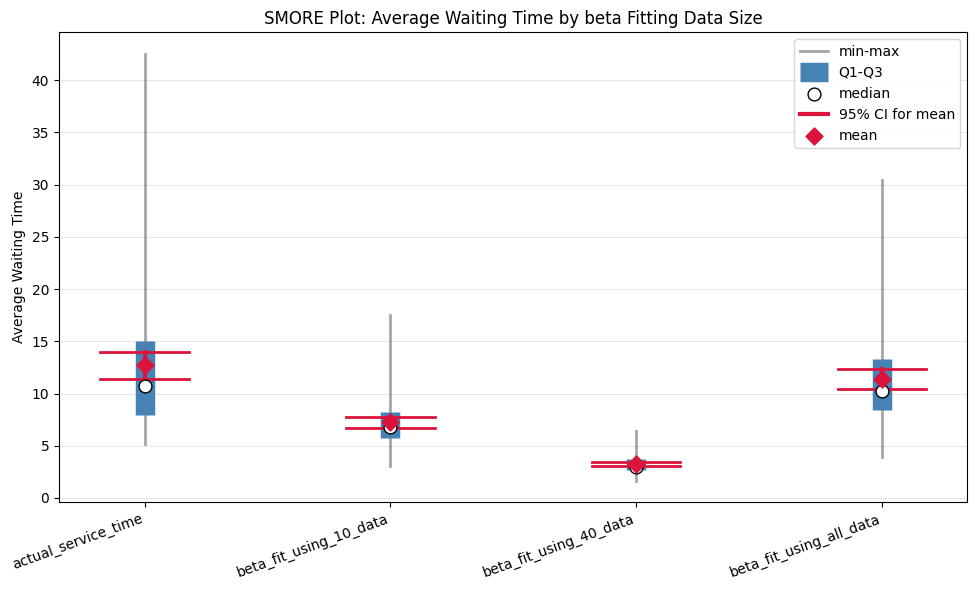

Saved: analysis_results/queue_output_comparison_by_beta_fit_size.csv


In [36]:
# Queueing simulation output comparison by fitting data size
# Service time scenarios:
# 1) actual service_time data sampled with replacement
# 2) fitted distribution using 10 service_time values
# 3) fitted distribution using 40 service_time values
# 4) fitted distribution using all service_time values
#
# Output metric for SMORE plot:
# - average waiting time

N_REPLICATIONS = 100
N_CUSTOMERS = 300
RANDOM_SEED = 2026

rng = np.random.default_rng(RANDOM_SEED)

mean_service_actual = np.mean(service_time_original)
mean_service_10_fit = fit_dist.mean(*params_10_data)
mean_service_40_fit = fit_dist.mean(*params_40_data)
mean_service_all_fit = fit_dist.mean(*params_all_data)

mean_service_candidates = np.array([
    mean_service_actual,
    mean_service_10_fit,
    mean_service_40_fit,
    mean_service_all_fit,
], dtype=float)

mean_service_candidates = mean_service_candidates[np.isfinite(mean_service_candidates)]
max_mean_service = np.max(mean_service_candidates)

TARGET_UTILIZATION_FOR_SLOWEST_SCENARIO = 0.80
ARRIVAL_RATE = TARGET_UTILIZATION_FOR_SLOWEST_SCENARIO / max_mean_service

print("Fixed arrival rate:", ARRIVAL_RATE)
print("Mean interarrival time:", 1 / ARRIVAL_RATE)

queue_fit_size_rows = []

scenario_order = [
    "actual_service_time",
    f"{FIT_DISTRIBUTION}_fit_using_10_data",
    f"{FIT_DISTRIBUTION}_fit_using_40_data",
    f"{FIT_DISTRIBUTION}_fit_using_all_data",
]

for replication in range(1, N_REPLICATIONS + 1):

    interarrival_time = rng.exponential(
        scale=1 / ARRIVAL_RATE,
        size=N_CUSTOMERS
    )

    arrival_time = np.cumsum(interarrival_time)

    for scenario in scenario_order:

        if scenario == "actual_service_time":
            service_time = rng.choice(
                service_time_original,
                size=N_CUSTOMERS,
                replace=True
            )

        elif scenario == f"{FIT_DISTRIBUTION}_fit_using_10_data":
            service_time = fit_dist.rvs(
                *params_10_data,
                size=N_CUSTOMERS,
                random_state=rng
            )

        elif scenario == f"{FIT_DISTRIBUTION}_fit_using_40_data":
            service_time = fit_dist.rvs(
                *params_40_data,
                size=N_CUSTOMERS,
                random_state=rng
            )

        else:
            service_time = fit_dist.rvs(
                *params_all_data,
                size=N_CUSTOMERS,
                random_state=rng
            )

        service_time = np.asarray(service_time, dtype=float)
        service_time = np.maximum(service_time, 0)

        start_time = np.zeros(N_CUSTOMERS)
        completion_time = np.zeros(N_CUSTOMERS)
        waiting_time = np.zeros(N_CUSTOMERS)
        time_in_system = np.zeros(N_CUSTOMERS)

        for i in range(N_CUSTOMERS):
            if i == 0:
                start_time[i] = arrival_time[i]
            else:
                start_time[i] = max(arrival_time[i], completion_time[i - 1])

            completion_time[i] = start_time[i] + service_time[i]
            waiting_time[i] = start_time[i] - arrival_time[i]
            time_in_system[i] = completion_time[i] - arrival_time[i]

        total_time = completion_time[-1] - arrival_time[0]
        busy_time = np.sum(service_time)
        utilization = busy_time / total_time
        throughput = N_CUSTOMERS / total_time

        max_queue_length = 0

        for t in arrival_time:
            queue_length_at_t = np.sum(
                (arrival_time <= t) &
                (start_time > t)
            )

            if queue_length_at_t > max_queue_length:
                max_queue_length = queue_length_at_t

        queue_fit_size_rows.append({
            "scenario": scenario,
            "replication": replication,
            "average_waiting_time": np.mean(waiting_time),
            "median_waiting_time": np.median(waiting_time),
            "average_time_in_system": np.mean(time_in_system),
            "median_time_in_system": np.median(time_in_system),
            "average_service_time": np.mean(service_time),
            "utilization": utilization,
            "throughput": throughput,
            "max_queue_length": max_queue_length,
        })

queue_fit_size_output_df = pd.DataFrame(queue_fit_size_rows)

display(queue_fit_size_output_df.head())

display(queue_fit_size_output_df.groupby("scenario").agg(
    replications=("replication", "count"),
    avg_waiting_time=("average_waiting_time", "mean"),
    std_waiting_time=("average_waiting_time", "std"),
    avg_time_in_system=("average_time_in_system", "mean"),
    avg_service_time=("average_service_time", "mean"),
    avg_utilization=("utilization", "mean"),
    avg_throughput=("throughput", "mean"),
    avg_max_queue_length=("max_queue_length", "mean"),
).reset_index())

queue_fit_size_output_df.to_csv(
    os.path.join(OUTDIR, f"queue_output_comparison_by_{FIT_DISTRIBUTION}_fit_size.csv"),
    index=False
)

SMORE_METRIC = "average_waiting_time"

smore_rows = []

for scenario in scenario_order:
    values = queue_fit_size_output_df.loc[
        queue_fit_size_output_df["scenario"] == scenario,
        SMORE_METRIC
    ].dropna().astype(float).to_numpy()

    n_smore = len(values)
    mean_smore = np.mean(values)
    std_smore = np.std(values, ddof=1)

    alpha_smore = 1 - CONFIDENCE
    t_smore = stats.t.ppf(1 - alpha_smore / 2, df=n_smore - 1)
    half_width_smore = t_smore * std_smore / np.sqrt(n_smore)

    smore_rows.append({
        "scenario": scenario,
        "n": n_smore,
        "min": np.min(values),
        "q1": np.quantile(values, 0.25),
        "median": np.median(values),
        "q3": np.quantile(values, 0.75),
        "max": np.max(values),
        "mean": mean_smore,
        "ci_lower": mean_smore - half_width_smore,
        "ci_upper": mean_smore + half_width_smore,
        "half_width": half_width_smore,
    })

waiting_time_fit_size_smore_summary = pd.DataFrame(smore_rows)
display(waiting_time_fit_size_smore_summary)

plt.figure(figsize=(10, 6))

x_positions = np.arange(len(waiting_time_fit_size_smore_summary))

for i, row in waiting_time_fit_size_smore_summary.iterrows():
    x_pos = x_positions[i]

    plt.plot(
        [x_pos, x_pos],
        [row["min"], row["max"]],
        color="gray",
        linewidth=2,
        alpha=0.7,
        label="min-max" if i == 0 else None,
    )

    plt.plot(
        [x_pos, x_pos],
        [row["q1"], row["q3"]],
        color="steelblue",
        linewidth=14,
        solid_capstyle="butt",
        label="Q1-Q3" if i == 0 else None,
    )

    plt.scatter(
        x_pos,
        row["median"],
        color="white",
        edgecolor="black",
        s=85,
        zorder=4,
        label="median" if i == 0 else None,
    )

    plt.plot(
        [x_pos, x_pos],
        [row["ci_lower"], row["ci_upper"]],
        color="crimson",
        linewidth=3,
        label=f"{int(CONFIDENCE * 100)}% CI for mean" if i == 0 else None,
    )

    plt.plot(
        [x_pos - 0.18, x_pos + 0.18],
        [row["ci_lower"], row["ci_lower"]],
        color="crimson",
        linewidth=2,
    )

    plt.plot(
        [x_pos - 0.18, x_pos + 0.18],
        [row["ci_upper"], row["ci_upper"]],
        color="crimson",
        linewidth=2,
    )

    plt.scatter(
        x_pos,
        row["mean"],
        color="crimson",
        marker="D",
        s=75,
        zorder=5,
        label="mean" if i == 0 else None,
    )

plt.xticks(
    x_positions,
    waiting_time_fit_size_smore_summary["scenario"],
    rotation=20,
    ha="right"
)

plt.ylabel("Average Waiting Time")
plt.title(f"SMORE Plot: Average Waiting Time by {FIT_DISTRIBUTION} Fitting Data Size")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Saved:",
    os.path.join(OUTDIR, f"queue_output_comparison_by_{FIT_DISTRIBUTION}_fit_size.csv")
)